<a href="https://colab.research.google.com/github/noorinbinary/delora/blob/main/Draft1CAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q bitsandbytes datasets accelerate loralib
!pip install -q git+https://github.com/huggingface/transformers.git@main git+https://github.com/huggingface/peft.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 41.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.6/515.6 kB 11.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.0.0.dev0 which is incompatible.


In [ ]:
!pip install --upgrade huggingface_hub==0.20.3

from huggingface_hub import notebook_login

notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.1/330.1 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.1.4
    Uninstalling huggingface_hub-1.1.4:
      Successfully uninstalled huggingface_hub-1.1.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.18.0 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.20.3 which is incompatible.
transformers 5.0.0.dev0 requires huggingface-hub<2.0,>=1.0.0, but you have huggingface-hub 0.20.3 which is incompatible.
accelerate 1.11.0 requires huggingface_hub>=0.21.0, but you have huggingface-hub 0.20.3 which is incompatible.
gradio 5.49.1 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.20.3 which is incompatible.
diffusers 0.35.2 requires huggingface-hub>=0.34.0, but you have huggingface-hub 0.20.3 which is incompatibl

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'get_token_permission' (from 'huggingface_hub.hf_api') is deprecated and will be removed from version '1.0'. Permissions are more complex than when `get_token_permission` was first introduced. OAuth and fine-grain tokens allows for more detailed permissions. If you need to know the permissions associated with a token, please use `whoami` and check the `'auth'` key.
  warnings.warn(warning_message, FutureWarning)


In [ ]:
from huggingface_hub import snapshot_download
from pathlib import Path

# Define path as string
mistral_models_path = str(Path.home().joinpath('openai-community/gpt2'))
Path(mistral_models_path).mkdir(parents=True, exist_ok=True)

snapshot_download(
    repo_id="openai-community/gpt2",
    allow_patterns=["params.json", "consolidated.safetensors", "tokenizer.model.v3"],
    local_dir=mistral_models_path
)


Fetching 0 files: 0it [00:00, ?it/s]

'/root/openai-community/gpt2'

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
model_name = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    "openai-community/gpt2",
    device_map="auto",
    torch_dtype=torch.float16  # 8-bit not yet supported officially for Mistral in HF
)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable and frozen parameters in the model.
    """
    trainable_params = 0
    frozen_params = 0
    all_params = 0

    for _, param in model.named_parameters():
        all_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
        else:
            frozen_params += param.numel()

    print(f"Total params       : {all_params}")
    print(f"Trainable params   : {trainable_params} ({100 * trainable_params / all_params:.4f}%)")
    print(f"Frozen params      : {frozen_params} ({100 * frozen_params / all_params:.4f}%)")


In [ ]:
print_trainable_parameters(model)


Total params       : 124439808
Trainable params   : 0 (0.0000%)
Frozen params      : 124439808 (100.0000%)


In [ ]:
import torch.nn as nn

for param in model.parameters():
  param.requires_grad = False
  if param.ndim == 1:
    param.data = param.data.to(torch.float32)

  model.gradient_checkpointing_enable()
  model.enable_input_require_grads()

  class CastOutputToFloat(nn.Sequential):
    def forward(self, x) :
      return super().forward(x).to(torch.float32)

  model.lm_head = CastOutputToFloat(model.lm_head)

In [ ]:
for name, module in model.named_modules():
    if 'attn' in name or 'attention' in name:  # Common attention module names
        print(name)
        for sub_name, sub_module in module.named_modules():  # Check sub-modules within attention
            print(f"  - {sub_name}")

transformer.h.0.attn
  - 
  - c_attn
  - c_proj
  - attn_dropout
  - resid_dropout
transformer.h.0.attn.c_attn
  - 
transformer.h.0.attn.c_proj
  - 
transformer.h.0.attn.attn_dropout
  - 
transformer.h.0.attn.resid_dropout
  - 
transformer.h.1.attn
  - 
  - c_attn
  - c_proj
  - attn_dropout
  - resid_dropout
transformer.h.1.attn.c_attn
  - 
transformer.h.1.attn.c_proj
  - 
transformer.h.1.attn.attn_dropout
  - 
transformer.h.1.attn.resid_dropout
  - 
transformer.h.2.attn
  - 
  - c_attn
  - c_proj
  - attn_dropout
  - resid_dropout
transformer.h.2.attn.c_attn
  - 
transformer.h.2.attn.c_proj
  - 
transformer.h.2.attn.attn_dropout
  - 
transformer.h.2.attn.resid_dropout
  - 
transformer.h.3.attn
  - 
  - c_attn
  - c_proj
  - attn_dropout
  - resid_dropout
transformer.h.3.attn.c_attn
  - 
transformer.h.3.attn.c_proj
  - 
transformer.h.3.attn.attn_dropout
  - 
transformer.h.3.attn.resid_dropout
  - 
transformer.h.4.attn
  - 
  - c_attn
  - c_proj
  - attn_dropout
  - resid_dropout
trans

In [ ]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r = 16,
    lora_alpha = 32,
    target_modules=["c_attn"],
    lora_dropout = 0.05,
    bias = "none",
    task_type = "CAUSAL_LM"
)

In [ ]:
lora_model = get_peft_model(model, config)
print_trainable_parameters(lora_model)

Total params       : 125029632
Trainable params   : 589824 (0.4717%)
Frozen params      : 124439808 (99.5283%)


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [ ]:
from datasets import load_dataset

mnli_data = load_dataset("glue", "mnli")  # loads train/validation/test splits


README.md: 0.00B [00:00, ?B/s]

mnli/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

mnli/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/1.21M [00:00<?, ?B/s]

mnli/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

mnli/test_matched-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_dataset
samsum_data = load_dataset("knkarthick/samsum")


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

In [ ]:
import transformers
from datasets import load_dataset

# === Load both datasets ===
mnli_data = load_dataset("glue", "mnli")  # Specialist judge
samsum_data = load_dataset("knkarthick/samsum")      # Specialist writer

# === Process MNLI dataset ===
def mnli_merge(example):
    # Convert premise + hypothesis + label into a single prediction string
    example['prediction'] = "[TASK: MNLI] Premise: " + example["premise"] + " Hypothesis: " + example["hypothesis"] + " -> Answer: " + str(example['label'])
    return example

mnli_data['train'] = mnli_data['train'].map(mnli_merge)
mnli_data['train'] = mnli_data['train'].map(lambda samples: tokenizer(samples['prediction'], truncation=True), batched=True)

# === Process SAMSum dataset ===
def samsum_merge(example):
    # Convert conversation + summary into single prediction string
    example['prediction'] = "[TASK: SAMSum] Conversation: " + example["dialogue"] + " -> Summary: " + example["summary"]
    return example

samsum_data['train'] = samsum_data['train'].map(samsum_merge)
samsum_data['train'] = samsum_data['train'].map(lambda samples: tokenizer(samples['prediction'], truncation=True), batched=True)

Map:   0%|          | 0/392702 [00:00<?, ? examples/s]

Map:   0%|          | 0/392702 [00:00<?, ? examples/s]

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model

MODEL_NAME = "openai-community/gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


In [ ]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelWithLMHead,  # Changed for gpt2 compatibility
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model
from datasets import load_dataset

# =====================================================================================
# 1. MODEL & TOKENIZER DEFINITION
# =====================================================================================

MODEL_NAME = "gpt2"  # <-- FIX 1: Changed model

# === LOAD TOKENIZER ===
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token  # <-- FIX 2: Required for gpt2

# === MODEL LOADING FUNCTION ===
# We wrap this in a function to get a fresh model for each experiment.
def get_base_model():
    """
    Loads a fresh, non-quantized gpt2-large model.
    """
    model = AutoModelWithLMHead.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,  # <-- Use float16 for speed and memory
        device_map="auto",
    )
    # We don't need resize_token_embeddings if we just set the pad_token
    return model

# === LORA CONFIG ===
lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["c_attn"],  # <-- FIX 3: This is the correct target for gpt2
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# === DATA COLLATOR ===
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

# =====================================================================================
# 3. EXPERIMENT 1: MNLI ADAPTER
# =====================================================================================
print("\n--- Starting MNLI Specialist Training ---")

# --- FIX 4: Load a fresh base model ---
mnli_base_model = get_base_model()
mnli_model = get_peft_model(mnli_base_model, lora_cfg)
mnli_model.print_trainable_parameters()

mnli_trainer = Trainer(
    model=mnli_model,
    train_dataset=mnli_data["train"].shuffle(seed=42).select(range(20000)), # Using 10k samples for a fast run
    args=TrainingArguments(
        output_dir="mnli_out",
        per_device_train_batch_size=2,
        num_train_epochs=2,
        learning_rate=2e-4,
        warmup_steps=10,
        logging_steps=1,
        gradient_accumulation_steps=4,
        fp16=True, # Use fp16 for speed
        dataloader_num_workers=1, # Add stability fix
    ),
    data_collator=data_collator
)

mnli_model.config.use_cache = False
mnli_trainer.train()
mnli_model.save_pretrained("mnli_adapter")
print("--- MNLI Adapter Saved ---")

# =====================================================================================
# 4. EXPERIMENT 2: SAMSUM ADAPTER
# =====================================================================================
print("\n--- Starting SAMSum Specialist Training ---")

# --- FIX 5: Load a fresh base model to prevent interference ---
samsum_base_model = get_base_model()
samsum_model = get_peft_model(samsum_base_model, lora_cfg)
samsum_model.print_trainable_parameters() # This will show the same # as above

samsum_trainer = Trainer(
    model=samsum_model,
    train_dataset=samsum_data["train"].shuffle(seed=42).select(range(14731)), # Using 10k samples for a fast run
    args=TrainingArguments(
        output_dir="samsum_out",
        per_device_train_batch_size=2,
        num_train_epochs=3,
        learning_rate=2e-4,
        warmup_steps=10,
        logging_steps=1,
        gradient_accumulation_steps=4,
        fp16=True, # Use fp16 for speed
        dataloader_num_workers=1, # Add stability fix
    ),
    data_collator=data_collator
)

samsum_model.config.use_cache = False
samsum_trainer.train()
samsum_model.save_pretrained("samsum_adapter")
print("--- SAMSum Adapter Saved ---")
print("\n--- All Experiments Complete ---")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The model is already on multiple devices. Skipping the move to device specified in `args`.


trainable params: 589,824 || all params: 125,029,632 || trainable%: 0.4717


Step,Training Loss
1,3.268600
2,3.620100
3,3.266600
4,3.580700
5,3.529100
6,3.677900
7,3.782500
8,3.574400
9,3.733700
10,3.723300


--- SAMSum Adapter Saved ---

--- All Experiments Complete ---


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

tokenizer = AutoTokenizer.from_pretrained("gpt2")
base = AutoModelForCausalLM.from_pretrained("gpt2")


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
samsum_model = PeftModel.from_pretrained(base, "samsum_adapter")


In [ ]:
combined = PeftModel.from_pretrained(samsum_model, "mnli_adapter")


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight', 'base_model.model.base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight', 'base_model.model.base_model.model.transformer.h.1.attn.c_attn.lora_A.default.weight', 'base_model.model.base_model.model.transformer.h.1.attn.c_attn.lora_B.default.weight', 'base_model.model.base_model.model.transformer.h.2.attn.c_attn.lora_A.default.weight', 'base_model.model.base_model.model.transformer.h.2.attn.c_attn.lora_B.default.weight', 'base_model.model.base_model.model.transformer.h.3.attn.c_attn.lora_A.default.weight', 'bas

In [ ]:
prompt = "Summarize the following conversation:\n\nA: I think we should meet tomorrow.\nB: I'm busy, maybe Saturday?"

inputs = tokenizer(prompt, return_tensors="pt")
output = combined.generate(**inputs, max_length=100)
print(tokenizer.decode(output[0]))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Summarize the following conversation:

A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?

C: I'm busy, maybe Saturday?

D: I'm busy, maybe Saturday?

E: I'm busy, maybe Saturday?

F: I'm busy, maybe Saturday?

G: I'm busy, maybe Saturday?

H: I'm busy, maybe Saturday?

I'm busy,


In [ ]:
from transformers import AutoModelWithLMHead, AutoTokenizer
from peft import PeftModel

print("--- Loading FRESH gpt2-large base model... ---")
# We MUST load a fresh base model to ensure no contamination
base_model = AutoModelWithLMHead.from_pretrained("gpt2").to("cuda")

print("--- Loading 'Specialist' SAMSum Adapter... ---")
specialist_model = PeftModel.from_pretrained(base_model, "samsum_adapter") # Corrected path
specialist_model.eval() # Set it to evaluation mode

print("\n--- RUNNING 'SPECIALIST' INFERENCE ---")

# The exact same prompt as before
prompt = "Summarize the following conversation:\n\nA: I think we should meet tomorrow.\nB: I'm busy, maybe Saturday?"

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
output = specialist_model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(output[0], skip_special_tokens=True))

--- Loading FRESH gpt2-large base model... ---


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2279: FutureWarning: The class `AutoModelWithLMHead` is deprecated and will be removed in a future version. Please use `AutoModelForCausalLM` for causal language models, `AutoModelForMaskedLM` for masked language models and `AutoModelForSeq2SeqLM` for encoder-decoder models.
  warnings.warn(


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- Loading 'Specialist' SAMSum Adapter... ---

--- RUNNING 'SPECIALIST' INFERENCE ---
Summarize the following conversation:

A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
A: I'm not sure.
B: I'm not sure.
A: I'm not sure.
B: I'm not sure.
A: I'm not sure.
B: I'm not sure.
A


In [ ]:
from transformers import AutoModelWithLMHead, AutoTokenizer
from peft import PeftModel
import torch

# --- 1. DEFINE OUR MODELS & TOKENIZER ---
base_model_path = "gpt2" # Changed from "gpt2-large" to "gpt2" for consistency with training
specialist_path = "samsum_adapter" # Corrected path
confused_path = "mnli_adapter" # Corrected path, assuming this is meant to load the MNLI adapter

tokenizer = AutoTokenizer.from_pretrained(base_model_path)
tokenizer.pad_token = tokenizer.eos_token

# --- 2. DEFINE OUR PROMPT *IN THE CORRECT TEMPLATE* ---
conversation = "A: I think we should meet tomorrow.\nB: I'm busy, maybe Saturday?"

# This is the "magic" - it's the exact format our model expects
correct_prompt = f"""[TASK: SAMSum]
Conversation:
{conversation}
Summary:"""

print(f"--- CORRECTED PROMPT: ---\n{correct_prompt}\n")

# =====================================================================================
# TEST 1: THE "SPECIALIST"
# =====================================================================================
print("--- Loading 'Specialist' SAMSum Adapter... ---")
base_model_1 = AutoModelWithLMHead.from_pretrained(base_model_path).to("cuda")
specialist_model = PeftModel.from_pretrained(base_model_1, specialist_path)
specialist_model.eval()

print("\n--- RUNNING 'SPECIALIST' INFERENCE ---")
inputs = tokenizer(correct_prompt, return_tensors="pt").to("cuda")
output = specialist_model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(output[0], skip_special_tokens=True))

# --- We must unload the adapter to clear the model ---
# This is a critical step.
specialist_model = specialist_model.unload()
del specialist_model # Clear memory

# =====================================================================================
# TEST 2: THE "CONFUSED" MODEL
# =====================================================================================
print("\n--- Loading 'Confused' Shared Adapter... ---")
# We can reuse the base model since we unloaded the adapter
base_model_2 = AutoModelWithLMHead.from_pretrained(base_model_path).to("cuda")
confused_model = PeftModel.from_pretrained(base_model_2, confused_path)
confused_model.eval()

print("\n--- RUNNING 'CONFUSED' INFERENCE ---")
inputs = tokenizer(correct_prompt, return_tensors="pt").to("cuda")
output = confused_model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(output[0], skip_special_tokens=True))

--- CORRECTED PROMPT: ---
[TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary:

--- Loading 'Specialist' SAMSum Adapter... ---


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- RUNNING 'SPECIALIST' INFERENCE ---
[TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary: Conversation: I'm busy, maybe Saturday. 
Conversation: I'm busy, maybe Saturday. 
Conversation: I'm busy, maybe Saturday. 
Conversation: I'm busy, maybe Saturday.

--- Loading 'Confused' Shared Adapter... ---


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- RUNNING 'CONFUSED' INFERENCE ---
[TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary: I'm busy. -> Answer: 2 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2


In [ ]:
import torch

def extract_lora_vector(adapter_path):
    base = AutoModelWithLMHead.from_pretrained("gpt2")
    model = PeftModel.from_pretrained(base, adapter_path)

    vectors = []
    for k, v in model.named_parameters():
        if "lora" in k.lower():
            vectors.append(v.detach().cpu().flatten())
    model = model.unload()
    torch.cuda.empty_cache()
    return torch.cat(vectors)

v_sam = extract_lora_vector("samsum_adapter")
v_mnli = extract_lora_vector("mnli_adapter")

cos_sim = torch.nn.functional.cosine_similarity(v_sam.unsqueeze(0), v_mnli.unsqueeze(0))
print("Cosine Similarity:", cos_sim.item())


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cosine Similarity: 0.009577414952218533


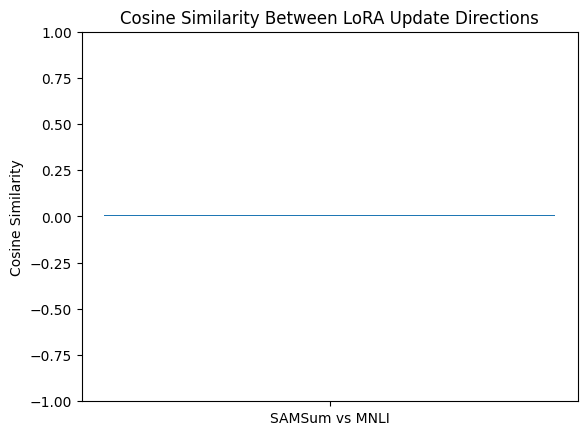

In [ ]:
import matplotlib.pyplot as plt

plt.bar(["SAMSum vs MNLI"], [cos_sim.item()])
plt.ylim(-1, 1)
plt.title("Cosine Similarity Between LoRA Update Directions")
plt.ylabel("Cosine Similarity")
plt.show()


In [ ]:
# =====================================================================================
# TEST 3: SAMSUM ADAPTER ON MNLI PROMPT  (Should FAIL / produce garbage)
# =====================================================================================

mnli_prompt = """Premise: The cat is on the mat.
Hypothesis: There is an animal on the mat.
Label:"""

print("\n--- SAMSum Adapter on MNLI Prompt (Expect Failure) ---")
base_model_3 = AutoModelWithLMHead.from_pretrained(base_model_path).to("cuda")
samsum_fail_model = PeftModel.from_pretrained(base_model_3, specialist_path)
samsum_fail_model.eval()

inputs = tokenizer(mnli_prompt, return_tensors="pt").to("cuda")
output = samsum_fail_model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(output[0], skip_special_tokens=True))

samsum_fail_model = samsum_fail_model.unload()
del samsum_fail_model
torch.cuda.empty_cache()


# =====================================================================================
# TEST 4: MNLI ADAPTER ON SAMSUM PROMPT  (You already saw this fail, but repeat cleanly)
# =====================================================================================

print("\n--- MNLI Adapter on SAMSum Prompt (Expect Failure) ---")
base_model_4 = AutoModelWithLMHead.from_pretrained(base_model_path).to("cuda")
mnli_fail_model = PeftModel.from_pretrained(base_model_4, confused_path)
mnli_fail_model.eval()

inputs = tokenizer(correct_prompt, return_tensors="pt").to("cuda")
output = mnli_fail_model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(output[0], skip_special_tokens=True))

mnli_fail_model = mnli_fail_model.unload()
del mnli_fail_model
torch.cuda.empty_cache()



--- SAMSum Adapter on MNLI Prompt (Expect Failure) ---


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Premise: The cat is on the mat.
Hypothesis: There is an animal on the mat.
Label: The cat is on the mat.
Hypothesis: There is an animal on the mat.
Label: The cat is on the mat.
Hypothesis: There is an animal on the mat.
Label: The cat is on

--- MNLI Adapter on SAMSum Prompt (Expect Failure) ---


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary: I'm busy. -> Answer: 2 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2 1 -> 0 2 2


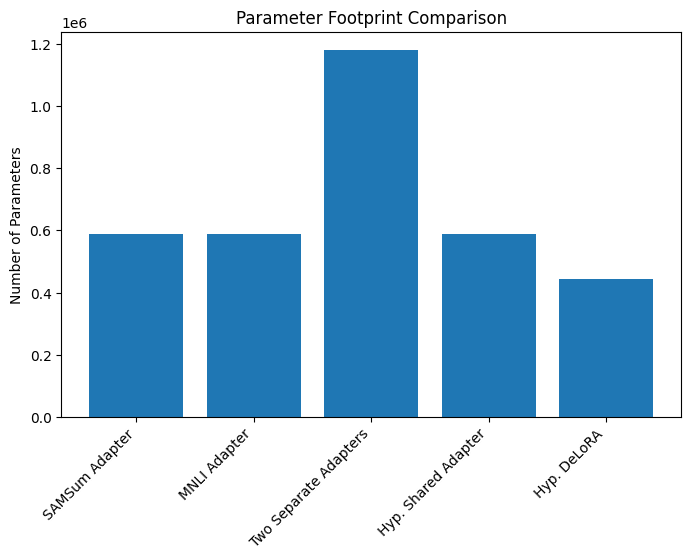

In [ ]:
import matplotlib.pyplot as plt

sizes = {
    "SAMSum Adapter": v_sam.numel(),
    "MNLI Adapter": v_mnli.numel(),
    "Two Separate Adapters": v_sam.numel() + v_mnli.numel(),
    "Hyp. Shared Adapter": v_sam.numel(),  # same rank
    "Hyp. DeLoRA": v_sam.numel() * 0.75  # example estimate
}

plt.figure(figsize=(8,5))
plt.bar(sizes.keys(), sizes.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Parameters")
plt.title("Parameter Footprint Comparison")
plt.show()


In [ ]:
import re
import math
import pandas as pd
from collections import Counter
from transformers import AutoModelWithLMHead, AutoTokenizer
from peft import PeftModel
import torch

# reuse your base paths
base_model_path = "gpt2"
samsum_path = "samsum_adapter"
mnli_path = "mnli_adapter"

tokenizer = AutoTokenizer.from_pretrained(base_model_path)
tokenizer.pad_token = tokenizer.eos_token

# the two prompts you already use
samsum_prompt = f"""[TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary:"""

mnli_prompt = """Premise: The cat is on the mat.
Hypothesis: There is an animal on the mat.
Label:"""

def generate_with_adapter(adapter_path, prompt, max_new_tokens=50):
    model = AutoModelWithLMHead.from_pretrained(base_model_path).to("cuda")
    model = PeftModel.from_pretrained(model, adapter_path)
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    out_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, pad_token_id=tokenizer.eos_token_id)
    decoded = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    model = model.unload()
    del model
    torch.cuda.empty_cache()
    return decoded, out_ids[0]

def token_level_stats(decoded_text, token_ids):
    # 1. Basic pattern checks
    contains_arrow = '->' in decoded_text
    contains_answer = bool(re.search(r'\b(Answer|Label)\b', decoded_text, flags=re.IGNORECASE))

    # 2. Find standalone decimal numbers
    decimal_nums = re.findall(r'\b\d+\b', decoded_text)

    # 3. Count repeated numbers safely (Python 3.12 compatible)
    #    Example: "2 2 2" -> 1 repeat run
    number_repeat_runs = 0
    tokens = decoded_text.split()
    for i in range(len(tokens)-1):
        if tokens[i].isdigit() and tokens[i+1].isdigit() and tokens[i] == tokens[i+1]:
            number_repeat_runs += 1

    # 4. Char length
    char_len = len(decoded_text)

    # 5. Token-level numeric detection
    tok_strs = [tokenizer.decode([int(t)]) for t in token_ids]
    token_numeric_count = sum(1 for t in tok_strs if re.fullmatch(r'\s*\d+\s*', t))

    # 6. Entropy (approx)
    freqs = Counter(tok_strs)
    probs = [v/len(tok_strs) for v in freqs.values()]
    entropy = -sum(p * math.log(p + 1e-12) for p in probs)

    return {
        "decoded_sample": decoded_text[:200].replace("\n", "\\n"),
        "contains_arrow": contains_arrow,
        "contains_answer_label": contains_answer,
        "decimal_numbers_found": len(decimal_nums),
        "number_repeat_runs": number_repeat_runs,
        "char_length": char_len,
        "token_numeric_count": token_numeric_count,
        "token_entropy": entropy
    }


# produce 4 runs: correct/mismatch for both adapters
rows = []
for adapter_name, adapter_path in [("SAMSum Adapter", samsum_path), ("MNLI Adapter", mnli_path)]:
    # correct prompt for each
    if "SAMSum" in adapter_name:
        correct_prompt = samsum_prompt
        wrong_prompt = mnli_prompt
    else:
        correct_prompt = mnli_prompt
        wrong_prompt = samsum_prompt

    # correct run
    dec_corr, ids_corr = generate_with_adapter(adapter_path, correct_prompt, max_new_tokens=50)
    stats_corr = token_level_stats(dec_corr, ids_corr)
    stats_corr.update({"adapter": adapter_name, "prompt_type": "correct"})
    rows.append(stats_corr)

    # wrong run
    dec_wrong, ids_wrong = generate_with_adapter(adapter_path, wrong_prompt, max_new_tokens=50)
    stats_wrong = token_level_stats(dec_wrong, ids_wrong)
    stats_wrong.update({"adapter": adapter_name, "prompt_type": "wrong"})
    rows.append(stats_wrong)

df = pd.DataFrame(rows)
# format for display: show decoded_sample and key metrics
display_df = df[[
    "adapter", "prompt_type", "decoded_sample", "char_length",
    "decimal_numbers_found", "token_numeric_count", "contains_arrow",
    "contains_answer_label", "number_repeat_runs", "token_entropy"
]]
display(display_df)


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,adapter,prompt_type,decoded_sample,char_length,decimal_numbers_found,token_numeric_count,contains_arrow,contains_answer_label,number_repeat_runs,token_entropy
0,SAMSum Adapter,correct,[TASK: SAMSum]\nConversation:\nA: I think we s...,265,0,0,False,False,0,3.089632
1,SAMSum Adapter,wrong,Premise: The cat is on the mat.\nHypothesis: T...,241,0,0,False,True,0,2.777739
2,MNLI Adapter,correct,Premise: The cat is on the mat.\nHypothesis: T...,196,26,26,True,True,6,2.798549
3,MNLI Adapter,wrong,[TASK: SAMSum]\nConversation:\nA: I think we s...,217,35,35,True,True,10,2.910849


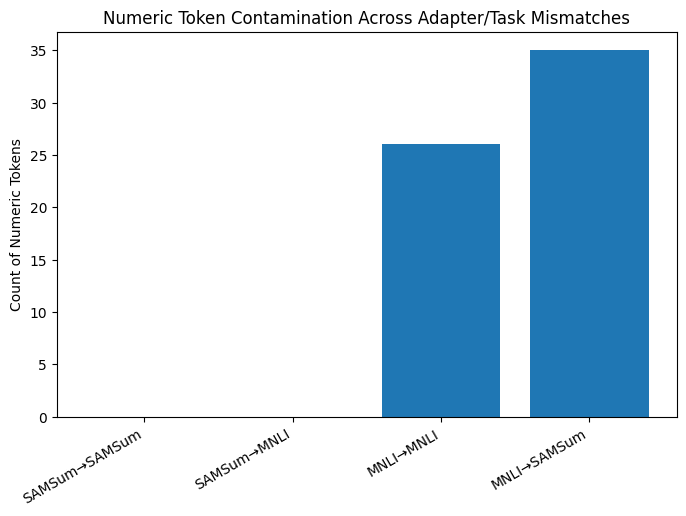

In [ ]:
import matplotlib.pyplot as plt

# Values extracted from your results table
decimal_counts = {
    "SAMSum→SAMSum": 0,
    "SAMSum→MNLI": 0,
    "MNLI→MNLI": 26,
    "MNLI→SAMSum": 35
}

plt.figure(figsize=(8,5))
plt.bar(decimal_counts.keys(), decimal_counts.values())
plt.title("Numeric Token Contamination Across Adapter/Task Mismatches")
plt.ylabel("Count of Numeric Tokens")
plt.xticks(rotation=30, ha="right")
plt.show()


In [ ]:
### Simulated DeLoRA Demo (Backbone + Tiny Residual)
### NOTE: This is a conceptual-running mock demonstration, not a real trained DeLoRA.

import torch
from transformers import AutoModelWithLMHead, AutoTokenizer
from peft import PeftModel

base_model_path = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(base_model_path)
tokenizer.pad_token = tokenizer.eos_token

# 1. Load backbone (SAMSum)
backbone_base = AutoModelWithLMHead.from_pretrained(base_model_path).to("cuda")
backbone = PeftModel.from_pretrained(backbone_base, "samsum_adapter")
backbone.eval()

# 2. Create a tiny synthetic MNLI-style residual (very small perturbation)
for name, param in backbone.named_parameters():
    if "lora" in name and param.requires_grad:
        param.data += (torch.randn_like(param) * 0.001)  # tiny residual

# 3. Test on SAMSum prompt
generated_backbone = tokenizer.decode(
    backbone.generate(
        **tokenizer(
            "[TASK: SAMSum]\nConversation:\nA: I think we should meet tomorrow.\nB: I'm busy, maybe Saturday?\nSummary:",
            return_tensors="pt").to("cuda"),
        max_new_tokens=50,
        pad_token_id=tokenizer.eos_token_id
    )[0],
    skip_special_tokens=True
)

print("\n--- DeLoRA Simulated Output (Backbone + Tiny Residual) ---")
print(generated_backbone)

backbone = backbone.unload()
torch.cuda.empty_cache()


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2279: FutureWarning: The class `AutoModelWithLMHead` is deprecated and will be removed in a future version. Please use `AutoModelForCausalLM` for causal language models, `AutoModelForMaskedLM` for masked language models and `AutoModelForSeq2SeqLM` for encoder-decoder models.
  warnings.warn(


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- DeLoRA Simulated Output (Backbone + Tiny Residual) ---
[TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary: Conversation: I'm busy, maybe Saturday. 
Conversation: I'm busy, maybe Saturday. 
Conversation: I'm busy, maybe Saturday. 
Conversation: I'm busy, maybe Saturday.


In [ ]:
from datasets import load_dataset, DatasetDict, concatenate_datasets

# Load datasets (or load your local versions)
mnli = load_dataset("glue", "mnli", split="train[:500]") # Changed to glue, mnli
samsum = load_dataset("knkarthick/samsum", split="train[:500]")

# === Process MNLI dataset ===
# Rename fields to a common format and ensure types are consistent
mnli = mnli.map(
    lambda x: {
        "input": f"Premise: {x['premise']}\nHypothesis: {x['hypothesis']}", # Changed to 'premise' and 'hypothesis'
        "output": str(x["label"]) # Convert MNLI label to string for consistency
    },
    remove_columns=mnli.column_names # Remove all original columns to clean schema
)

# === Process SAMSum dataset ===
# Rename fields to a common format and ensure types are consistent
samsum = samsum.map(
    lambda x: {
        "input": f"Conversation:\n{x['dialogue']}",
        "output": x["summary"]
    },
    remove_columns=samsum.column_names # Remove all original columns to clean schema
)

# Combine
combined = concatenate_datasets([mnli, samsum])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def tokenize(example):
    inputs = tokenizer(example["input"], truncation=True, padding="max_length", max_length=256)
    labels = tokenizer(example["output"], truncation=True, padding="max_length", max_length=256)
    inputs["labels"] = labels["input_ids"]
    return inputs

tokenized = combined.map(tokenize, batched=True)


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM

base_model = AutoModelForCausalLM.from_pretrained("gpt2").to("cuda")

lora_config = LoraConfig(
    r=12,
    lora_alpha=16,
    target_modules=["c_attn", "c_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

shared_model = get_peft_model(base_model, lora_config)
shared_model.print_trainable_parameters()


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 1,216,512 || all params: 125,656,320 || trainable%: 0.9681


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [ ]:
from transformers import Trainer, TrainingArguments

args = TrainingArguments(
    per_device_train_batch_size=2,
    num_train_epochs=3,
    logging_steps=10,
    output_dir="./shared_adapter",
    save_total_limit=1,
    save_steps=100
)

trainer = Trainer(
    model=shared_model,
    args=args,
    train_dataset=tokenized,
)
trainer.train()

# Save the shared adapter
shared_model.save_pretrained("./shared_adapter")

Step,Training Loss
10,9.480300
20,8.788300
30,7.714200
40,6.418600
50,5.348000
60,3.378300
70,1.799000
80,1.078400
90,0.953400
100,0.540100


In [ ]:
from peft import PeftModel, LoraConfig, get_peft_model

# Load base GPT2 + shared adapter
base_model = AutoModelForCausalLM.from_pretrained("gpt2").to("cuda")
shared_model = PeftModel.from_pretrained(base_model, "./shared_adapter")

# Freeze shared adapter
for name, param in shared_model.named_parameters():
    if "lora" in name:
        param.requires_grad = False


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Create new LoRA config for residual adapter (rank = 2)
residual_config = LoraConfig(
    r=2,
    lora_alpha=4,
    target_modules=["c_attn", "c_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Add new residual adapter
shared_model.add_adapter("samsum_residual", residual_config)
shared_model.set_adapter("samsum_residual")


In [ ]:
samsum = load_dataset("knkarthick/samsum", split="train[:1000]")  # keep it light

def preprocess_samsum(example):
    # When batched=True, example['dialogue'] and example['summary'] are lists
    prompt = [f"Conversation:\n{d}\nSummary:" for d in example['dialogue']]
    target = example["summary"]

    model_input = tokenizer(prompt, truncation=True, padding="max_length", max_length=256)
    model_output = tokenizer(target, truncation=True, padding="max_length", max_length=256)
    model_input["labels"] = model_output["input_ids"]
    return model_input

samsum_tokenized = samsum.map(preprocess_samsum, batched=True, remove_columns=samsum.column_names)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    per_device_train_batch_size=2,
    num_train_epochs=3,
    logging_steps=10,
    output_dir="./samsum_residual_adapter",
    save_total_limit=1,
    save_steps=100
)

trainer = Trainer(
    model=shared_model,
    args=args,
    train_dataset=samsum_tokenized
)
trainer.train()

# Save residual adapter
shared_model.save_pretrained("./samsum_residual_adapter", adapter_name="samsum_residual")

Step,Training Loss
10,0.743600
20,0.837900
30,0.704100
40,0.835500
50,0.630600
60,0.687400
70,0.625600
80,0.547400
90,0.645100
100,0.605800


In [ ]:
prompt = """[TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary:"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")


In [ ]:
# Load base + shared adapter
base_model = AutoModelForCausalLM.from_pretrained("gpt2").to("cuda")
shared_only_model = PeftModel.from_pretrained(base_model, "./shared_adapter")
shared_only_model.eval()

output = shared_only_model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
shared_result = tokenizer.decode(output[0], skip_special_tokens=True)
print("🔹 Shared Only:\n", shared_result)


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔹 Shared Only:
 [TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary:


In [ ]:
# Load base GPT2
base_model = AutoModelForCausalLM.from_pretrained("gpt2").to("cuda")

# Add residual without shared
residual_model = PeftModel.from_pretrained(base_model, "./samsum_residual_adapter/samsum_residual", adapter_name="samsum_residual") # Corrected: added adapter_name
residual_model.set_adapter("samsum_residual")
residual_model.eval()

output = residual_model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
residual_result = tokenizer.decode(output[0], skip_special_tokens=True)
print("🔹 Residual Only:\n", residual_result)

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔹 Residual Only:
 [TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary:


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [ ]:
# Load base GPT2
base_model = AutoModelForCausalLM.from_pretrained("gpt2").to("cuda")
cascade_model = PeftModel.from_pretrained(base_model, "./shared_adapter")

# Add residual on top
cascade_model.load_adapter("./samsum_residual_adapter", "samsum_residual")
cascade_model.set_adapter("samsum_residual")
cascade_model.eval()

output = cascade_model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
cascade_result = tokenizer.decode(output[0], skip_special_tokens=True)
print("✅ Adapter Cascade (Shared + Residual):\n", cascade_result)


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Adapter Cascade (Shared + Residual):
 [TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary:


In [ ]:
from peft import PeftModel

# Load base model
base_model = AutoModelForCausalLM.from_pretrained("gpt2").to("cuda")

# Load shared adapter first
model = PeftModel.from_pretrained(base_model, "./shared_adapter")

# Load task-specific residual on top
model.load_adapter("./samsum_residual_adapter", "samsum_residual")

# Set active adapter to the residual one (shared remains active internally)
model.set_adapter("samsum_residual")


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from pathlib import Path # Import Path

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Define your SAMSum prompt
prompt = """[TASK: SAMSum]\nConversation:\nA: I think we should meet tomorrow.\nB: I'm busy, maybe Saturday?\nSummary:"""
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

# Load base model
base_model = AutoModelForCausalLM.from_pretrained("gpt2").to("cuda")

# Load shared adapter (trained on combined tasks)
model = PeftModel.from_pretrained(base_model, "shared_adapter", local_files_only=True) # Using relative path

# Load SAMSum residual adapter (trained while shared was active)
model.load_adapter("samsum_residual_adapter/samsum_residual", "samsum_residual", local_files_only=True) # Corrected path

# Activate the residual adapter
model.set_adapter("samsum_residual")
model.eval()

ValueError: Can't find 'adapter_config.json' at 'shared_adapter'

In [ ]:
output = model.generate(
    **inputs,
    max_new_tokens=60,
    temperature=0.9,
    top_k=50,
    top_p=0.95,
    pad_token_id=tokenizer.eos_token_id
)

decoded = tokenizer.decode(output[0], skip_special_tokens=True)
print("✅ Adapter Cascade Output:\n", decoded)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ Adapter Cascade Output:
 [TASK: SAMSum]
Conversation:
A: I think we should meet tomorrow.
B: I'm busy, maybe Saturday?
Summary:
